# 1. Final MoE streamflow forecasting analysis

This notebook reviews the completed Khipu experiments using saved final artifacts. It compares persistence, individual experts on validation, and three hard Mixture-of-Experts (MoE) configurations. It performs analysis only: no model training, label generation, checkpoint loading, or inference.

**Evidence:** `outputs/final_results/validation_summary.csv` and `test_summary.csv` are authoritative for their consolidated comparisons. Supporting JSON and per-horizon CSV files are checked for consistency. The smoke prediction file is excluded.

Run with Python, NumPy, pandas, matplotlib, and IPython. Core tables and plots need only the lightweight evidence and `Input/metadata.json`. Saved notebook outputs support review without private datasets. Optional binary horizon curves and physical-consistency checks use local prediction CSVs and targets. Figure PNGs are exported under `outputs/final_results/figures/` (ignored generated files).


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Locate the repository from its root or the notebooks directory.
ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / "README.md").is_file() and (p / "src/routing.py").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run from the repository root or notebooks directory.")
RESULTS = ROOT / "outputs/final_results"
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

EVIDENCE = [
    "validation_summary.csv", "test_summary.csv", "test_metrics_binary_moe.json",
    "test_moe_lstm_metrics.json", "test_persistence_metrics.json",
    "router_lstm_gru_metrics.json", "router_lstm_informer_metrics.json",
    "moe_lstm_baseline_validation.json", "moe_lstm_gru_validation.json",
    "moe_lstm_informer_validation.json", "test_moe_lstm_by_horizon.csv",
    "test_persistence_by_horizon.csv",
]
missing = [name for name in EVIDENCE if not (RESULTS / name).is_file()]
if missing:
    raise FileNotFoundError(f"Missing lightweight evidence: {missing}")

def read_json(path):
    with path.open(encoding="utf-8") as stream:
        return json.load(stream)

metadata = read_json(ROOT / "Input/metadata.json")
LABELS = {
    "Persistence": "Persistence",
    "LSTM": "LSTM", "GRU": "GRU", "Informer": "Informer", "Seq2Seq": "Seq2Seq",
    "MoE_LSTM_Informer": "MoE: LSTM + Informer",
    "MoE_LSTM_GRU": "MoE: LSTM + GRU",
    "MoE_4class_LSTM_router": "Four-expert MoE (LSTM router)",
}
EXPERT_LABELS = {"lstm": "LSTM", "gru": "GRU", "seq2seq": "Seq2Seq", "informer": "Informer"}
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 180, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})
def show_figure(fig, filename):
    fig.savefig(FIGURES / filename, bbox_inches="tight")
    display(Image(filename=str(FIGURES / filename)))
    plt.close(fig)

def metric_bars(frame, metric, title, filename, xlabel=None):
    fig, ax = plt.subplots(figsize=(8, max(3.2, 0.48 * len(frame) + 1.4)), layout="constrained")
    values = frame[metric].to_numpy(dtype=float)
    bars = ax.barh([LABELS.get(m, m) for m in frame.index], values)
    ax.invert_yaxis()
    ax.set(title=title, xlabel=xlabel or metric.upper(), ylabel="Model")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)
    ax.margins(x=0.23)
    for bar, value in zip(bars, values):
        ax.annotate(f"{value:.5f}", (value, bar.get_y() + bar.get_height() / 2),
                    xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
    show_figure(fig, filename)

print("Analysis inputs: outputs/final_results/")
print("Figure exports: outputs/final_results/figures/")


Analysis inputs: outputs/final_results/
Figure exports: outputs/final_results/figures/


## 2. Problem definition

Given 336 hourly observations (14 days) with 12 input channels, forecast the next 48 hourly values of **specific_discharge**:

$$f:\mathbb{R}^{336\times12}\rightarrow\mathbb{R}^{48}.$$

The target is channel 11 of historical inputs. The forecast contains discharge only; future meteorological observations are not available to the models. Metadata declares target units as mm/h based on the source variable name, without a conversion. Error plots use those declared units.


## 3. Dataset and official splits

Training uses `Input/train-001.h5`: `split=0` is training and `split=1` is validation. The official split is retained; no random split is introduced. `Input/test.h5` contains `X` and `basin_id`, without targets.

The course provider confirmed that `Input/test_targets.csv` row **Id=i corresponds exactly to test.h5 X[i]**. Held-out test metrics are final. Validation supports model/checkpoint selection; test targets are reserved for final evaluation. Counts below come from `Input/metadata.json`.


In [2]:
split_table = pd.DataFrame([
    {"Split": "Train", "HDF5 split code": "0", "Samples": metadata["samples"]["train"]},
    {"Split": "Validation", "HDF5 split code": "1", "Samples": metadata["samples"]["validation"]},
    {"Split": "Test", "HDF5 split code": "separate test.h5", "Samples": metadata["samples"]["test"]},
])
display(split_table.set_index("Split"))
assert metadata["history_hours"] == 336 and metadata["forecast_hours"] == 48
assert metadata["target_channel"] == 11 and len(metadata["channels"]) == 12


,HDF5 split code,Samples
Split,,
Train,0,254000
Validation,1,18142
Test,separate test.h5,27983


## 4. Input/output tensor structure

Here, B denotes batch size and N the number of selected experts.

| Tensor | Shape | Role |
|---|---|---|
| X | [B, 336, 12] | Historical model input |
| y | [B, 48] | Future specific_discharge truth |
| y_aux | [B, 48, 11] | Future meteorological variables; unused |
| Expert forecast stack | [B, N, 48] | One forecast per selected expert |
| Router class | [B] | One local expert index per sample |
| Final forecast | [B, 48] | Selected forecast in physical units |

`basin_id` and `Id` are metadata, not model input channels. The output CSV contains `Id` and `q_01` through `q_48`.


In [3]:
display(pd.DataFrame(metadata["channels"])[["index", "name"]].set_index("index"))


,name
index,
0,convective_fraction
1,longwave_radiation
2,potential_energy
3,potential_evaporation
4,pressure
5,shortwave_radiation
6,specific_humidity
7,temperature
8,total_precipitation


## 5. Preprocessing

Channel-wise input statistics and scalar target statistics are computed **only on training data** and stored in `outputs/train_stats.json` and model artifacts:

$$x'_{t,c}=\frac{x_{t,c}-\mu_{c,\mathrm{train}}}{\sigma_{c,\mathrm{train}}},\qquad
y'_h=\frac{y_h-\mu_{y,\mathrm{train}}}{\sigma_{y,\mathrm{train}}}.$$

A zero input standard deviation uses divisor one; target standard deviation must be positive. Predictions return to physical units via $\hat y_h=\sigma_y\hat y'_h+\mu_y$ before evaluation. Router and expert normalization metadata must agree.

For Seq2Seq, the initial decoder discharge is the last **raw** channel-11 value normalized with target statistics. It is not the channel-standardized input value. Neither `basin_id` nor future `y_aux` enters the model input. See `src/training.py` and `src/preprocessing.py`.


## 6. Persistence baseline and evaluation metrics

Persistence repeats the last observed specific_discharge value across all 48 future hours:

$$\hat y(t+h)=y(t),\qquad h=1,\ldots,48.$$

Its constant 48-value forecast is compared with the actual 48-hour target using the same metrics as the MoEs. This is implemented in `src/baseline.py`.

For M evaluated sample–horizon values:

$$\mathrm{MAE}=\frac{1}{M}\sum_{j=1}^{M}|y_j-\hat y_j|,$$
$$\mathrm{RMSE}=\sqrt{\frac{1}{M}\sum_{j=1}^{M}(y_j-\hat y_j)^2},$$
$$\mathrm{NSE}=1-\frac{\sum_{j=1}^{M}(y_j-\hat y_j)^2}{\sum_{j=1}^{M}(y_j-\bar y)^2}.$$

Lower MAE and RMSE are preferable; higher NSE is preferable. NSE=1 is perfect; NSE=0 matches the squared-error performance of predicting the observed mean; NSE<0 is worse than that mean reference. NSE is undefined for zero target variance.

The repository accumulates global errors across sample–horizon values; this is not a mean of basin-wise NSE values. This notebook reads the authoritative global test metrics and does not replace them with a different aggregation.


## 7. Expert architectures

| Expert | Implemented architecture |
|---|---|
| LSTM | LSTM history encoder and direct 48-step projection |
| GRU | GRU history encoder and direct 48-step projection |
| Seq2Seq | LSTM encoder, additive/Bahdanau attention, autoregressive LSTM decoder |
| Informer | Input projection, relative sinusoidal positions, simplified ProbSparse encoder, distillation, causal decoder, and 48-step output |

Seq2Seq teacher forcing is used only during training. Informer uses full causal decoder self-attention and full cross-attention; no explicit calendar embeddings or future meteorological values are assumed. This is the repository's adapted implementation, not a claim of exact reproduction of the paper.

Experts train independently with normalized-target MSE and are frozen before router-label generation. See `src/models/experts.py`, `src/models/informer.py`, and `ARCHITECTURE.md`.


## 8. Router architectures

| Router | Historical representation | Output |
|---|---|---|
| Random Forest | Flattened normalized 336 × 12 history | Local expert class |
| LSTM | LSTM sequence encoder | N-class head |
| Transformer | Projected history, sinusoidal positions, Transformer encoder, mean pooling | N-class head |

The three architectures are supported by `src/models/routers.py`. The final MoE comparisons here use **LSTM routers**; these artifacts do not establish a final performance comparison across all three router architectures. Neural routers supplied with validation labels select the checkpoint by validation cross-entropy loss.


## 9. Hard Mixture-of-Experts methodology

For sample i, oracle expert labels minimize MAE over the complete forecast horizon:

$$e_i^*=\arg\min_{e\in\{0,\ldots,N-1\}}\frac{1}{48}
\sum_{h=1}^{48}|y_{i,h}-\hat y_{i,e,h}|.$$

Ties select the first local class. The router learns $r(X_i)$ from historical inputs. Inference computes the selected expert stack and returns

$$\hat y_{i,h}=\hat y_{i,r(X_i),h},\qquad h=1,\ldots,48.$$

One expert supplies all 48 values for a sample. There is no soft averaging and no horizon-specific routing. The router consumes normalized history, not future targets or expert forecasts. Router accuracy measures agreement with oracle classes; it is **not forecast accuracy**.


## 10. Four-expert MoE baseline

The original full configuration has the local mapping:

| Class | Expert |
|---:|---|
| 0 | LSTM |
| 1 | GRU |
| 2 | Seq2Seq |
| 3 | Informer |

The baseline combines these four frozen experts with an LSTM router. Its validation evidence is `moe_lstm_baseline_validation.json`; its final test evidence is `test_moe_lstm_metrics.json` and the consolidated test summary. The original mapping remains supported for legacy four-class router artifacts.


## 11. Configurable expert subsets

The extension accepts ordered subsets of canonical public names: `lstm`, `gru`, `seq2seq`, `informer`. Public `seq2seq` maps to internal model name `seq2seq_attention`.

Router IDs are local contiguous indices in the **exact requested order**, and router artifacts store `expert_names`. Evaluation and test inference reconstruct the selected expert list from that metadata; an explicit subset must match it exactly. Only selected experts are loaded.

| Requested subset | Local class 0 | Local class 1 |
|---|---|---|
| lstm,informer | LSTM | Informer |
| lstm,gru | LSTM | GRU |

Using the original global 0/1/2/3 IDs would misidentify experts in arbitrary subsets. The extension changes participation and class mapping, not expert architectures. See `src/routing.py` and `src/inference.py`.


## 12. Two-class ablations

**LSTM + Informer:** a paper-inspired two-expert experiment pairing recurrent and attention-based architectures. Architectural complementarity is a motivation, not a demonstrated statistical independence of their errors. Local classes are 0=LSTM, 1=Informer.

**LSTM + GRU:** a data-driven ablation motivated by the individual recurrent experts' validation performance. Local classes are 0=LSTM, 1=GRU.

The experimental sequence was: four-class baseline → configurable subsets → LSTM + Informer → LSTM + GRU → final held-out test comparison. Each binary experiment uses an LSTM router.


## 13. Validation results

Source: `outputs/final_results/validation_summary.csv`. Individual-expert entries have fewer stored decimal places than the MoE entries; formatting does not increase their measurement precision. Comparisons below are metric-specific and contain no composite score.


,MAE,RMSE,NSE
model,,,
LSTM,0.022999,0.102133,0.645735
GRU,0.023240,0.101180,0.652330
Informer,0.024510,0.102610,0.642390
Seq2Seq,0.038670,0.108080,0.603290
MoE: LSTM + Informer,0.022081,0.101700,0.648734
MoE: LSTM + GRU,0.021523,0.100350,0.657999
Four-expert MoE (LSTM router),0.021471,0.101719,0.648607


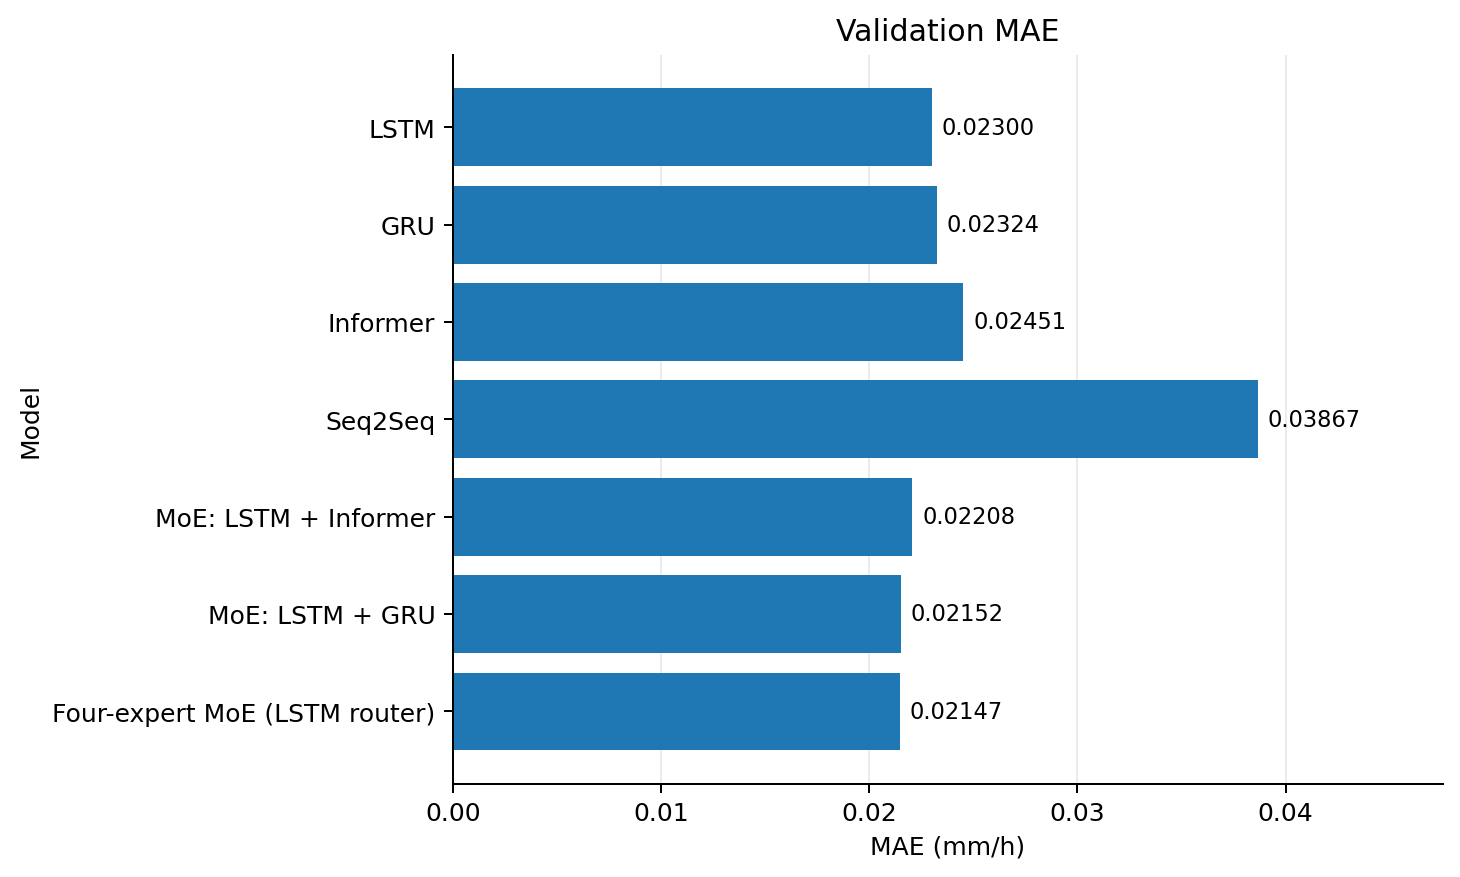

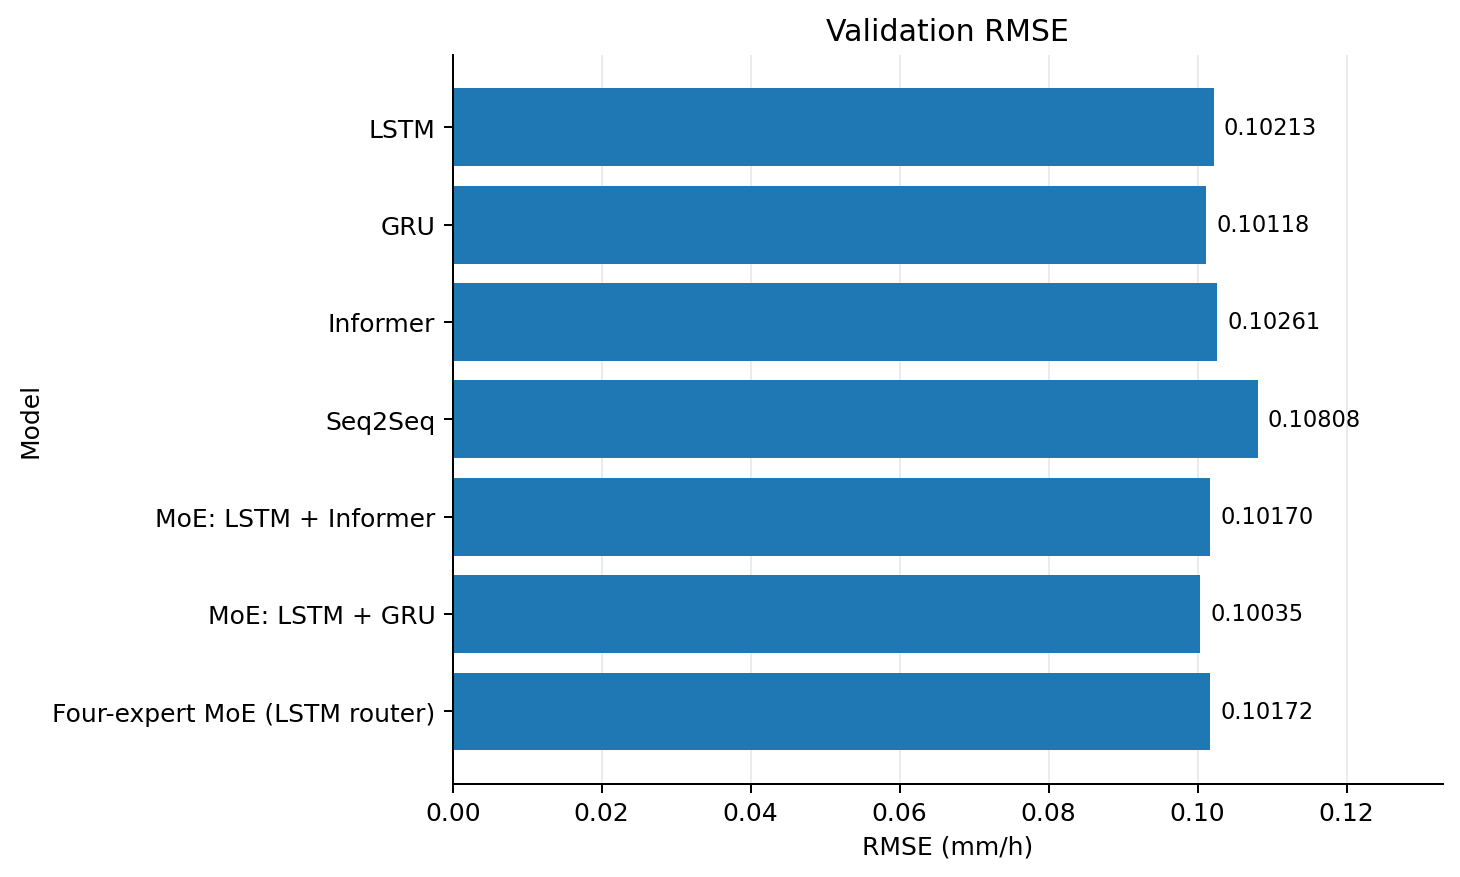

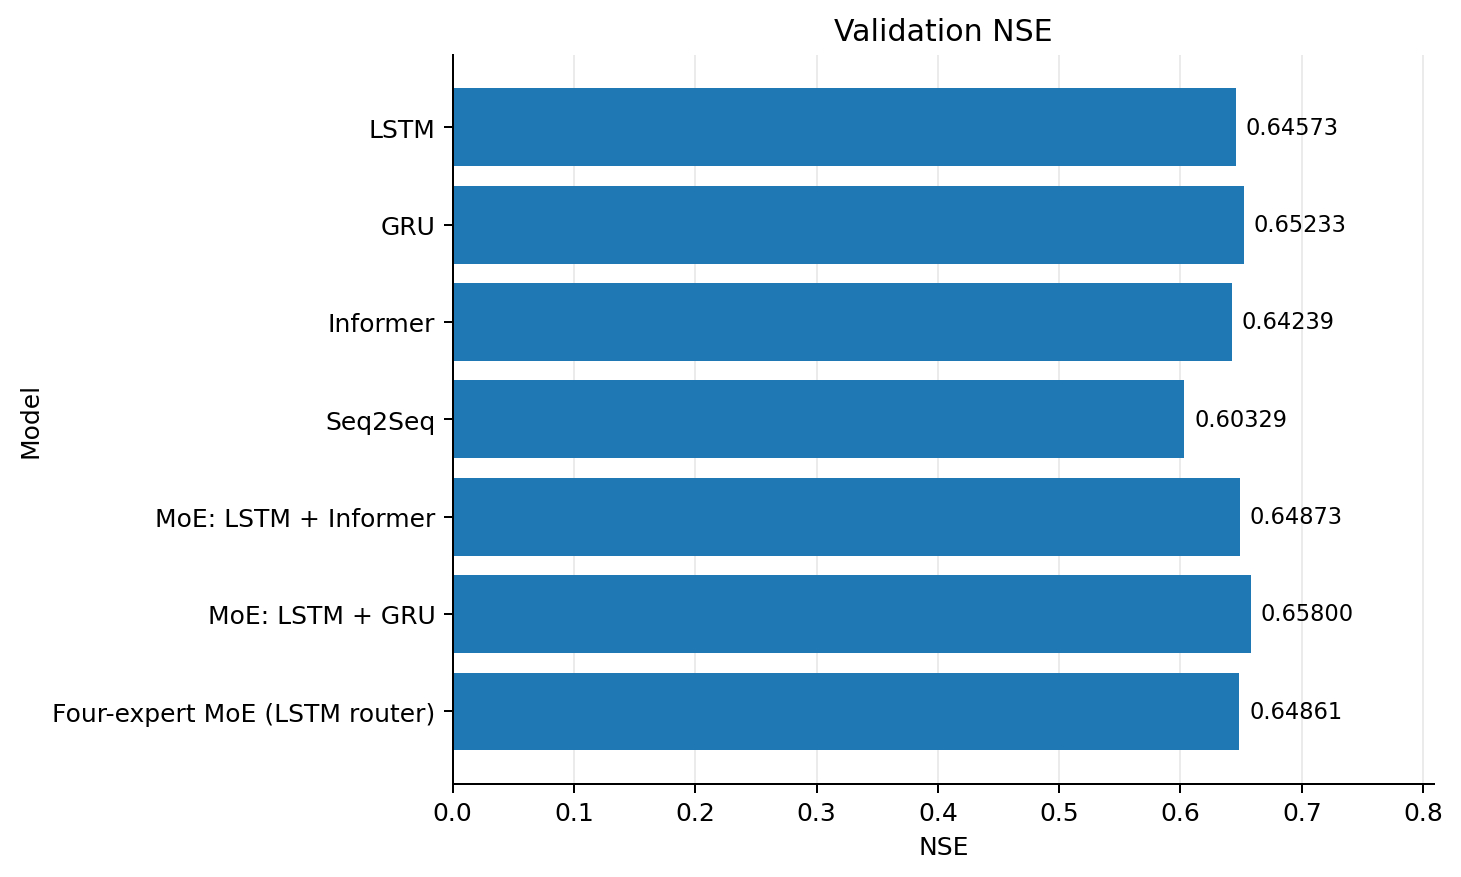

In [4]:
validation = pd.read_csv(RESULTS / "validation_summary.csv").set_index("model")
expected_validation = ["LSTM", "GRU", "Informer", "Seq2Seq",
                      "MoE_LSTM_Informer", "MoE_LSTM_GRU", "MoE_4class_LSTM_router"]
assert validation.index.is_unique and set(validation.index) == set(expected_validation)
assert np.isfinite(validation[["mae", "rmse", "nse"]].to_numpy()).all()
MOE_FILES = {
    "MoE_4class_LSTM_router": "moe_lstm_baseline_validation.json",
    "MoE_LSTM_Informer": "moe_lstm_informer_validation.json",
    "MoE_LSTM_GRU": "moe_lstm_gru_validation.json",
}
moe_validation = {model: read_json(RESULTS / name) for model, name in MOE_FILES.items()}
for model, record in moe_validation.items():
    assert record["n_samples"] == metadata["samples"]["validation"]
    for metric in ["mae", "rmse", "nse"]:
        assert np.isclose(validation.loc[model, metric], record["global"][metric],
                          rtol=1e-12, atol=1e-12)
display(validation.rename(index=LABELS, columns=str.upper).style.format("{:.6f}"))
for metric in ["mae", "rmse", "nse"]:
    metric_bars(validation, metric, f"Validation {metric.upper()}",
                f"validation_{metric}.png",
                xlabel=f"{metric.upper()} (mm/h)" if metric != "nse" else "NSE")


The four-expert MoE has the lowest validation MAE (0.021471), narrowly below LSTM + GRU (0.021523). LSTM + GRU has the lowest validation RMSE (0.100350) and highest NSE (0.657999) among the reported models. Among individual experts, LSTM has the lowest MAE and GRU the lowest RMSE and highest NSE. These results motivated examination of the recurrent pair, without establishing statistical significance.


## 14. Router performance

Sources: `router_lstm_informer_metrics.json` and `router_lstm_gru_metrics.json`. Loss is validation cross-entropy; accuracy is oracle-class agreement. Rows of each confusion matrix are true oracle classes, and columns are predicted classes.


In [5]:
router_files = {
    "MoE_LSTM_Informer": "router_lstm_informer_metrics.json",
    "MoE_LSTM_GRU": "router_lstm_gru_metrics.json",
}
routers = {model: read_json(RESULTS / name) for model, name in router_files.items()}
router_rows, frequency_rows = [], []
for model, record in routers.items():
    names = record["expert_names"]
    assert names == (["lstm", "informer"] if model == "MoE_LSTM_Informer" else ["lstm", "gru"])
    cm = np.asarray(record["confusion_matrix"], dtype=int)
    assert cm.shape == (2, 2) and cm.sum() == metadata["samples"]["validation"]
    np.testing.assert_array_equal(cm.sum(axis=0), record["predicted_class_frequency"])
    np.testing.assert_array_equal(cm.sum(axis=1), record["true_class_frequency"])
    assert np.isclose(np.trace(cm) / cm.sum(), record["validation_accuracy"])
    np.testing.assert_array_equal(cm, moe_validation[model]["router_confusion_matrix"])
    router_rows.append({
        "Model": LABELS[model], "Selected epoch": record["best_epoch"],
        "Validation loss": record["validation_loss"],
        "Oracle-class accuracy (%)": 100 * record["validation_accuracy"],
    })
    for local_id, name in enumerate(names):
        frequency_rows.append({
            "Model": LABELS[model], "Local class": local_id, "Expert": EXPERT_LABELS[name],
            "True frequency": int(cm[local_id].sum()),
            "Predicted frequency": int(cm[:, local_id].sum()),
        })
router_table = pd.DataFrame(router_rows).set_index("Model")
display(router_table.style.format({"Validation loss": "{:.6f}", "Oracle-class accuracy (%)": "{:.2f}"}))
display(pd.DataFrame(frequency_rows).set_index(["Model", "Local class"]))


,Selected epoch,Validation loss,Oracle-class accuracy (%)
Model,,,
MoE: LSTM + Informer,10,0.561776,70.88
MoE: LSTM + GRU,8,0.538955,71.95


Expert  True frequency  Predicted frequency
Model                Local class                                               
MoE: LSTM + Informer 0                LSTM           10933                13046
                     1            Informer            7209                 5096
MoE: LSTM + GRU      0                LSTM           11448                13022
                     1                 GRU            6694                 5120

## 15. Final held-out test results

`outputs/final_results/test_summary.csv` is the authoritative consolidated comparison on 27,983 test samples. Its improvement columns are retained and checked against the stated formulas.

Two older supporting JSON files contain a historical assumption note written before external confirmation. That note is superseded by the provider-confirmed **Id=i ↔ X[i]** correspondence. The stored metric values are preserved; these final test results are not provisional.


,MAE,RMSE,NSE,MAE improvement (%),RMSE improvement (%),Delta NSE
model,,,,,,
Persistence,0.024610,0.118795,0.495640,0.00,0.00,+0.000000
MoE: LSTM + Informer,0.023453,0.101500,0.631808,4.71,14.56,+0.136169
MoE: LSTM + GRU,0.023377,0.101593,0.631130,5.01,14.48,+0.135491
Four-expert MoE (LSTM router),0.023055,0.102171,0.626920,6.32,13.99,+0.131280


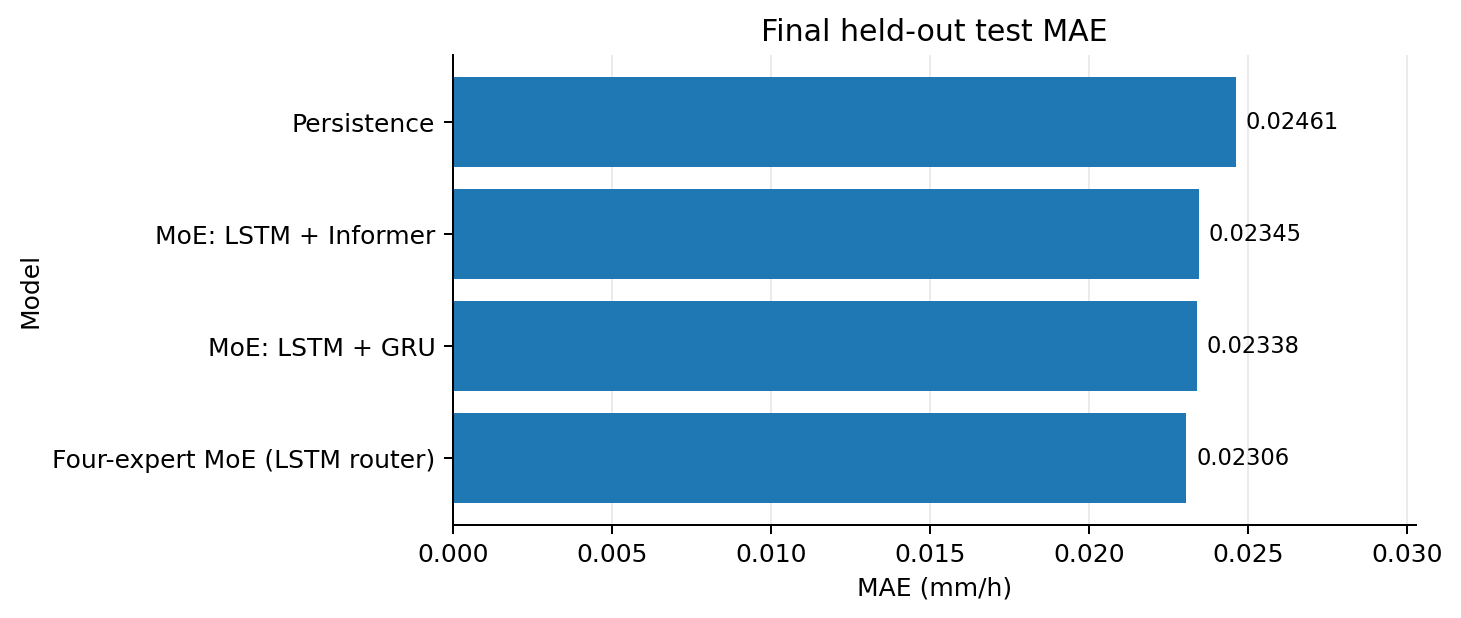

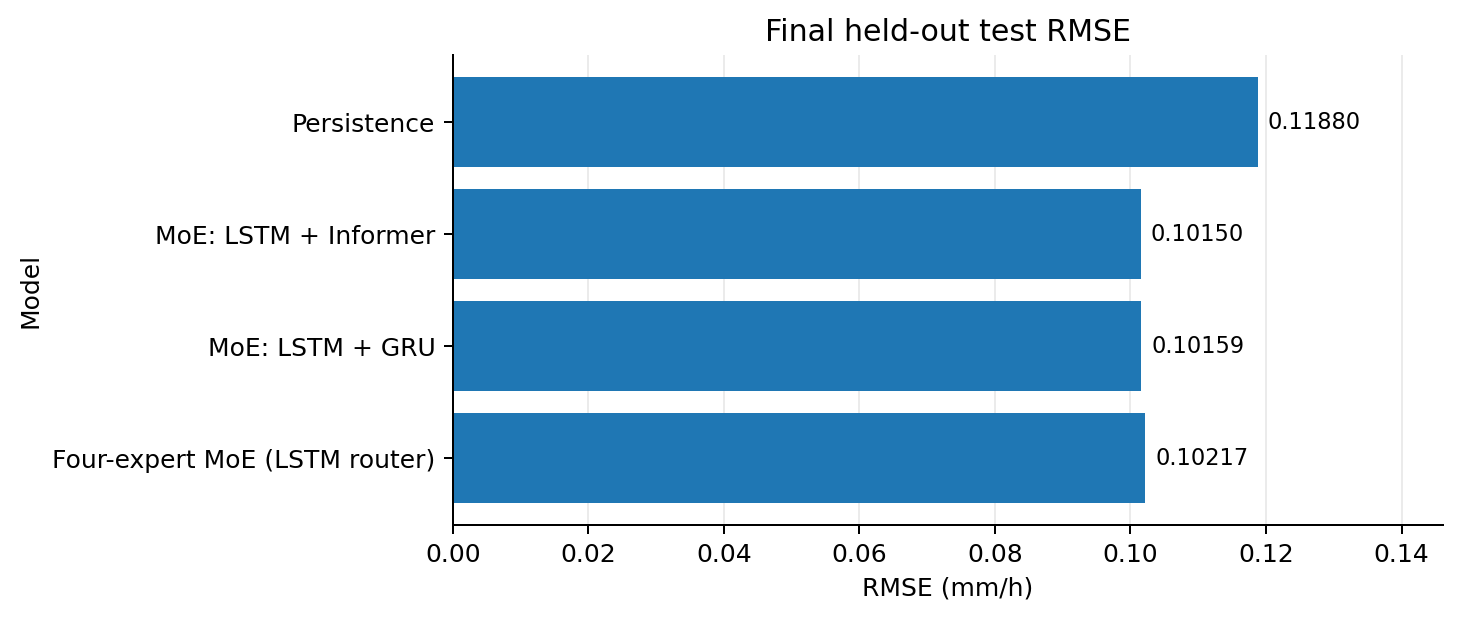

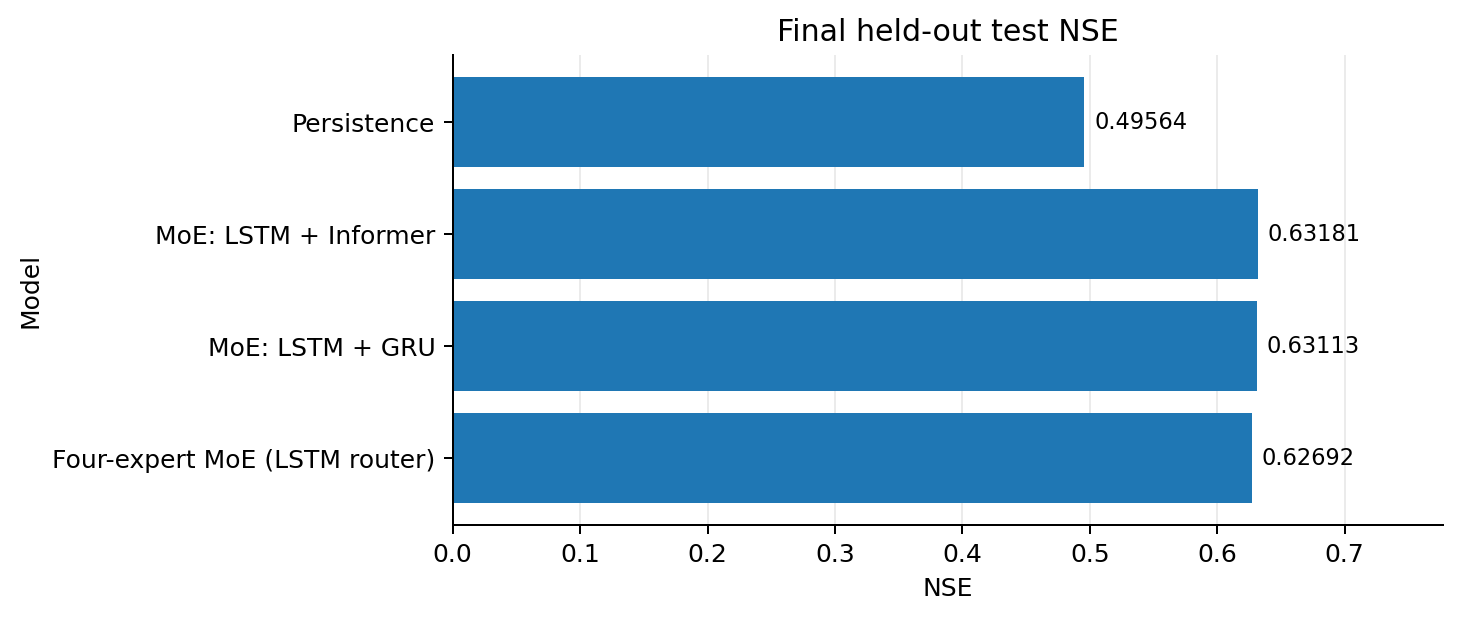

In [6]:
test = pd.read_csv(RESULTS / "test_summary.csv").set_index("model")
assert test.index.is_unique
assert set(test.index) == {"Persistence", *MOE_FILES}
assert np.isfinite(test.to_numpy(dtype=float)).all()
binary_metrics = read_json(RESULTS / "test_metrics_binary_moe.json")
for model, filename in [
    ("Persistence", "test_persistence_metrics.json"),
    ("MoE_4class_LSTM_router", "test_moe_lstm_metrics.json"),
]:
    record = read_json(RESULTS / filename)
    assert record["n_samples"] == metadata["samples"]["test"]
    for metric in ["mae", "rmse", "nse"]:
        assert np.isclose(test.loc[model, metric], record[metric], rtol=1e-12, atol=1e-12)
for model, record in binary_metrics.items():
    assert record["n_samples"] == metadata["samples"]["test"]
    for metric in ["mae", "rmse", "nse"]:
        assert np.isclose(test.loc[model, metric], record[metric.upper()], rtol=1e-12, atol=1e-12)
reference = test.loc["Persistence"]
for metric in ["mae", "rmse"]:
    expected = (reference[metric] - test[metric]) / reference[metric] * 100
    np.testing.assert_allclose(test[f"{metric}_improvement_vs_persistence_pct"], expected,
                               rtol=1e-10, atol=1e-10)
np.testing.assert_allclose(test["delta_nse_vs_persistence"], test["nse"] - reference["nse"])
test_columns = {
    "mae": "MAE", "rmse": "RMSE", "nse": "NSE",
    "mae_improvement_vs_persistence_pct": "MAE improvement (%)",
    "rmse_improvement_vs_persistence_pct": "RMSE improvement (%)",
    "delta_nse_vs_persistence": "Delta NSE",
}
display(test.rename(index=LABELS, columns=test_columns).style.format({
    "MAE": "{:.6f}", "RMSE": "{:.6f}", "NSE": "{:.6f}",
    "MAE improvement (%)": "{:.2f}", "RMSE improvement (%)": "{:.2f}",
    "Delta NSE": "{:+.6f}",
}))
for metric in ["mae", "rmse", "nse"]:
    metric_bars(test, metric, f"Final held-out test {metric.upper()}",
                f"test_{metric}.png",
                xlabel=f"{metric.upper()} (mm/h)" if metric != "nse" else "NSE")


All three MoEs improve over persistence on test MAE, RMSE, and NSE. The four-class MoE has the lowest reported MoE MAE (0.023055). LSTM + Informer has the lowest RMSE (0.101500) and highest NSE (0.631808). LSTM + GRU is close on RMSE/NSE and has lower MAE than LSTM + Informer. These are metric-specific differences, not an overall ranking.


## 16. Improvement versus persistence

$$I_{\mathrm{MAE}}=100\frac{\mathrm{MAE}_{P}-\mathrm{MAE}_{M}}{\mathrm{MAE}_{P}},\qquad
I_{\mathrm{RMSE}}=100\frac{\mathrm{RMSE}_{P}-\mathrm{RMSE}_{M}}{\mathrm{RMSE}_{P}},$$
$$\Delta\mathrm{NSE}=\mathrm{NSE}_{M}-\mathrm{NSE}_{P}.$$

P denotes persistence and M a model. Positive values indicate improvement. NSE is reported as an **absolute difference**, not a percentage improvement.


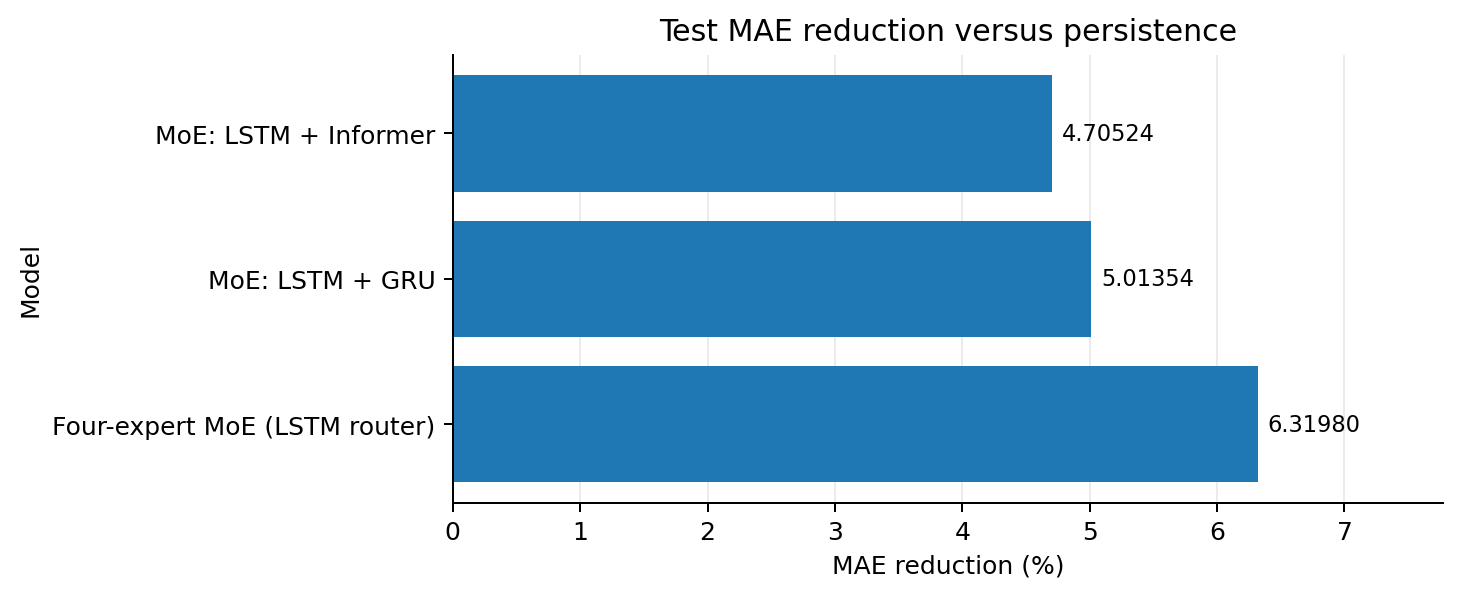

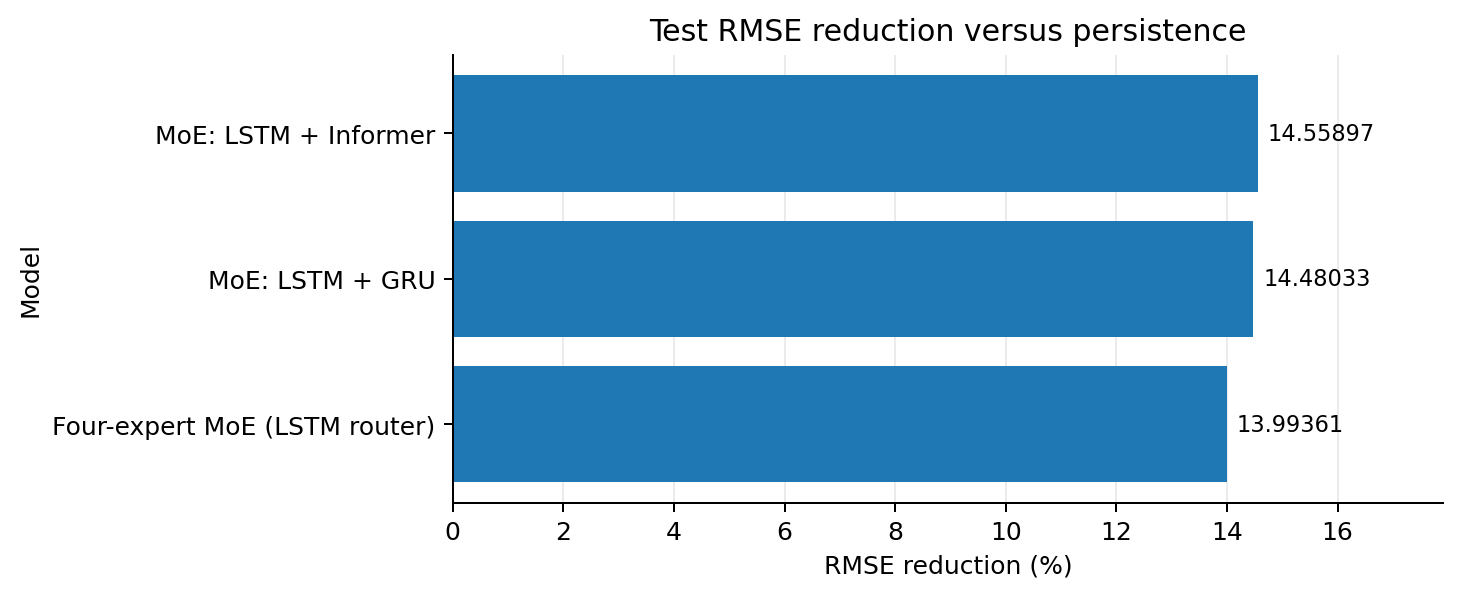

,MAE improvement (%),RMSE improvement (%),Delta NSE
model,,,
MoE: LSTM + Informer,4.7052,14.5590,0.1362
MoE: LSTM + GRU,5.0135,14.4803,0.1355
Four-expert MoE (LSTM router),6.3198,13.9936,0.1313


In [7]:
test_moe = test.drop(index="Persistence")
for metric in ["mae", "rmse"]:
    metric_bars(test_moe, f"{metric}_improvement_vs_persistence_pct",
                f"Test {metric.upper()} reduction versus persistence",
                f"test_{metric}_improvement.png", xlabel=f"{metric.upper()} reduction (%)")
display(test_moe[["mae_improvement_vs_persistence_pct", "rmse_improvement_vs_persistence_pct",
                  "delta_nse_vs_persistence"]].rename(index=LABELS, columns=test_columns)
        .style.format("{:.4f}"))


## 17. Per-horizon analysis

The saved `test_moe_lstm_by_horizon.csv` and `test_persistence_by_horizon.csv` describe the four-expert MoE with LSTM router and persistence, respectively.

When local targets and binary prediction files are present, the following cell derives binary MAE/RMSE separately at each horizon after joining by Id. It checks unique IDs, complete test-row coverage, all 48 columns, and finite values. It never reruns inference or replaces global test metrics. Optional analyses are skipped with a message if their local inputs are absent.


Derived binary horizon curves: MoE_LSTM_Informer, MoE_LSTM_GRU
Four-expert MoE (LSTM router): lower MAE than persistence at 37/48 horizons.
Four-expert MoE (LSTM router): lower RMSE than persistence at 47/48 horizons.
MoE: LSTM + Informer: lower MAE than persistence at 36/48 horizons.
MoE: LSTM + Informer: lower RMSE than persistence at 47/48 horizons.
MoE: LSTM + GRU: lower MAE than persistence at 38/48 horizons.
MoE: LSTM + GRU: lower RMSE than persistence at 47/48 horizons.


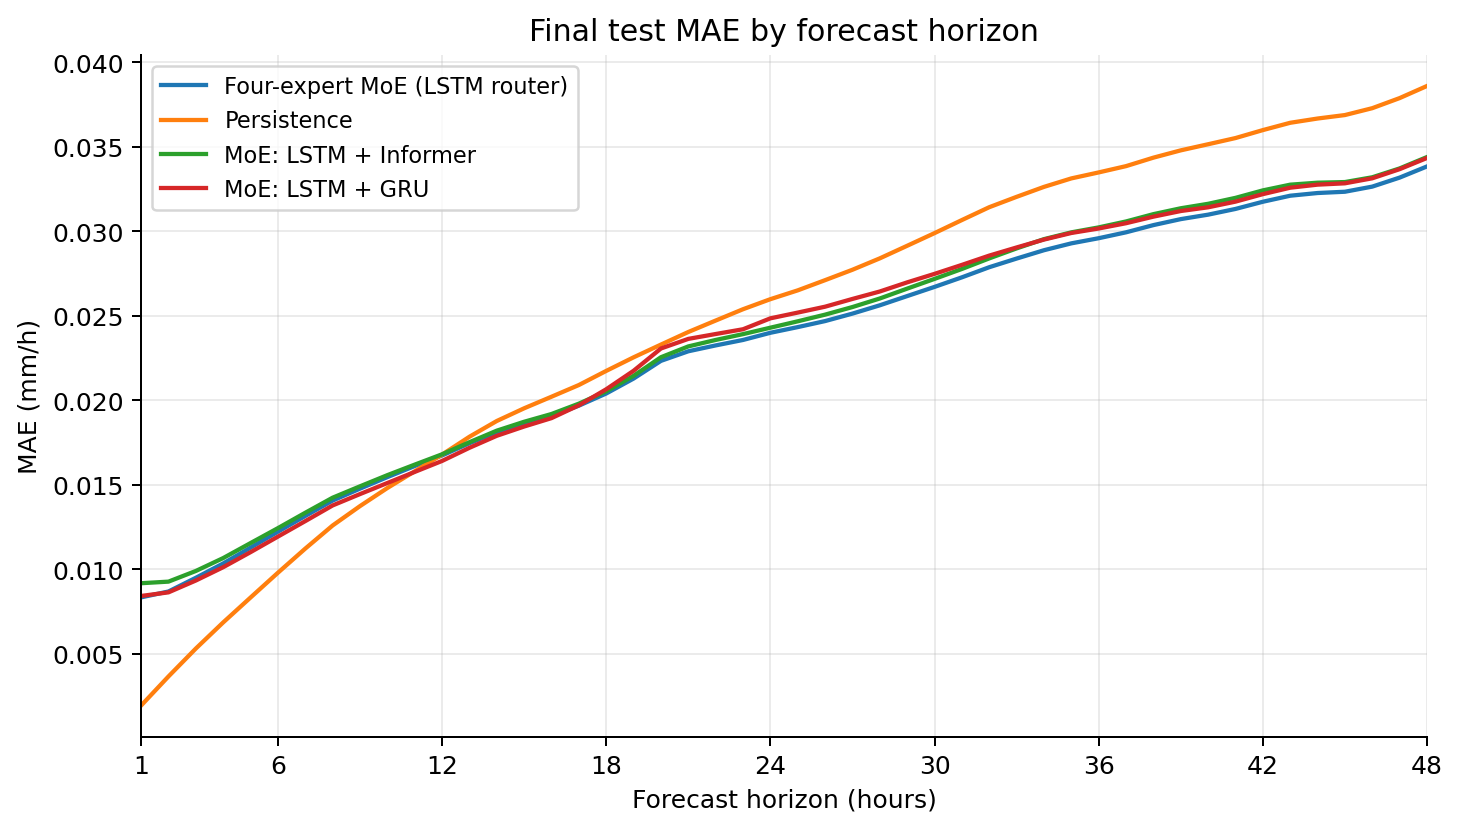

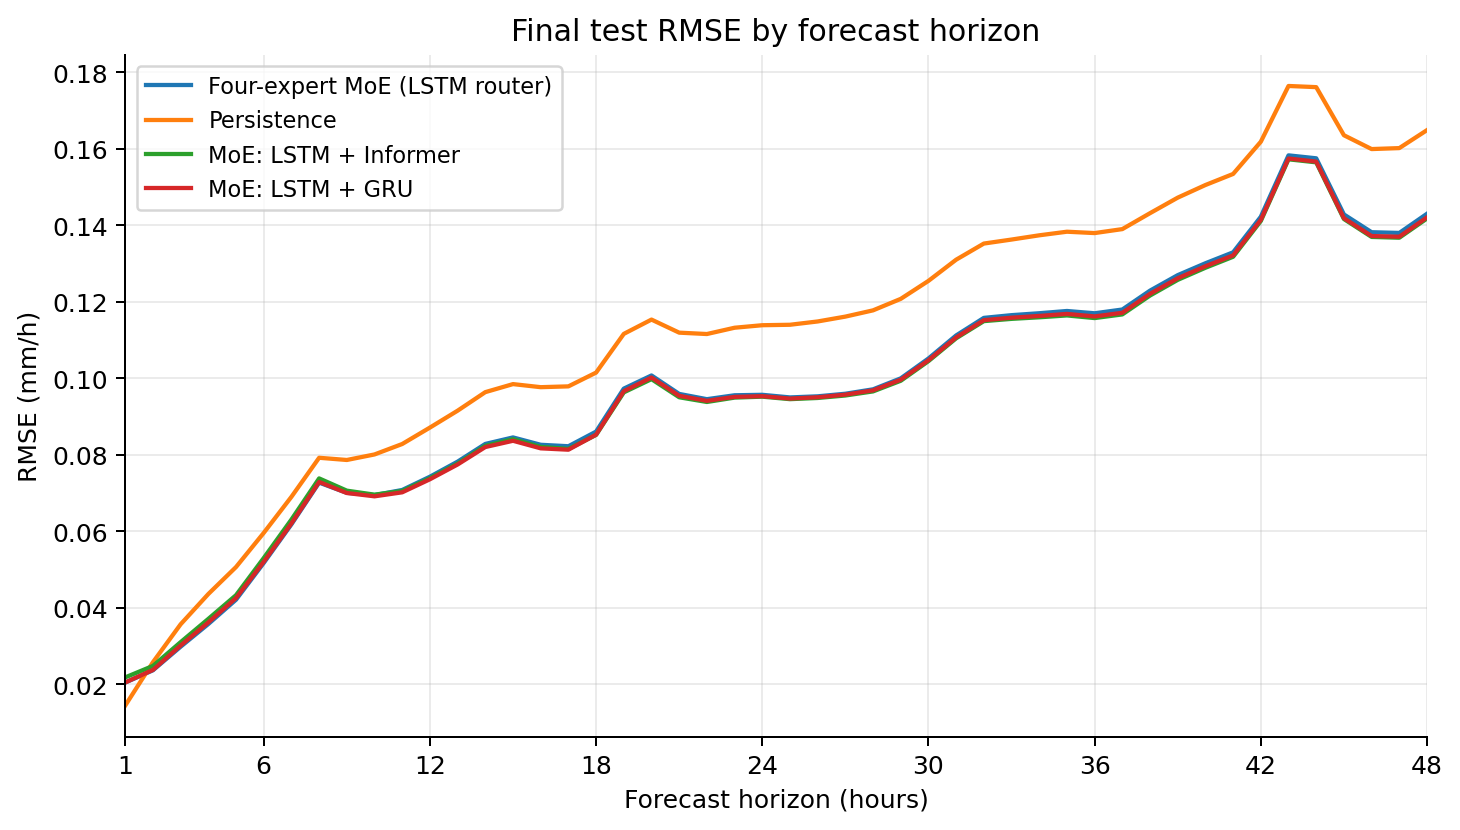

In [8]:
horizon_curves = {}
for model, filename in [
    ("MoE_4class_LSTM_router", "test_moe_lstm_by_horizon.csv"),
    ("Persistence", "test_persistence_by_horizon.csv"),
]:
    frame = pd.read_csv(RESULTS / filename)
    np.testing.assert_array_equal(frame["horizon"], np.arange(1, 49))
    assert np.isfinite(frame[["mae", "rmse"]].to_numpy()).all()
    horizon_curves[model] = frame

q_columns = [f"q_{h:02d}" for h in range(1, 49)]
expected_ids = np.arange(metadata["samples"]["test"])

def read_forecast_csv(path):
    frame = pd.read_csv(path)
    if list(frame.columns) != ["Id", *q_columns]:
        raise ValueError(f"Unexpected columns in {path.name}")
    if not pd.api.types.is_integer_dtype(frame["Id"]) or not frame["Id"].is_unique:
        raise ValueError(f"Non-integer or duplicate IDs in {path.name}")
    frame = frame.set_index("Id").sort_index()
    np.testing.assert_array_equal(frame.index.to_numpy(), expected_ids)
    if not np.isfinite(frame[q_columns].to_numpy(dtype=float)).all():
        raise ValueError(f"Non-finite values in {path.name}")
    return frame

prediction_files = {
    "MoE_LSTM_Informer": "test_predictions_lstm_informer.csv",
    "MoE_LSTM_GRU": "test_predictions_lstm_gru.csv",
}
predictions = {}
for model, filename in prediction_files.items():
    if (RESULTS / filename).is_file():
        predictions[model] = read_forecast_csv(RESULTS / filename)
    else:
        print(f"Skipped optional prediction analysis: {filename} is not available.")

target_path = ROOT / "Input/test_targets.csv"
derived_binary_models = []
if target_path.is_file():
    targets = read_forecast_csv(target_path)
    for model, frame in predictions.items():
        truth = targets.loc[frame.index, q_columns].to_numpy(dtype=np.float64)
        error = frame[q_columns].to_numpy(dtype=np.float64) - truth
        horizon_curves[model] = pd.DataFrame({
            "horizon": np.arange(1, 49),
            "mae": np.abs(error).mean(axis=0),
            "rmse": np.sqrt(np.square(error).mean(axis=0)),
        })
        derived_binary_models.append(model)
    print("Derived binary horizon curves:", ", ".join(derived_binary_models) or "none")
else:
    print("Skipped binary horizon curves: Input/test_targets.csv is not available.")

for metric in ["mae", "rmse"]:
    fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
    for model, frame in horizon_curves.items():
        ax.plot(frame["horizon"], frame[metric], label=LABELS[model], linewidth=1.7)
    ax.set(title=f"Final test {metric.upper()} by forecast horizon",
           xlabel="Forecast horizon (hours)", ylabel=f"{metric.upper()} (mm/h)",
           xlim=(1, 48), xticks=[1, 6, 12, 18, 24, 30, 36, 42, 48])
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
    show_figure(fig, f"test_horizon_{metric}.png")

horizon_rows = []
for model, frame in horizon_curves.items():
    for horizon in [1, 24, 48]:
        row = frame.loc[frame["horizon"] == horizon].iloc[0]
        horizon_rows.append({"Model": LABELS[model], "Horizon (h)": horizon,
                             "MAE": row["mae"], "RMSE": row["rmse"]})
display(pd.DataFrame(horizon_rows).set_index(["Model", "Horizon (h)"]).style.format("{:.6f}"))
persistence_curve = horizon_curves["Persistence"]
for model, frame in horizon_curves.items():
    if model == "Persistence":
        continue
    for metric in ["mae", "rmse"]:
        lower = int((frame[metric].to_numpy() < persistence_curve[metric].to_numpy()).sum())
        print(f"{LABELS[model]}: lower {metric.upper()} than persistence at {lower}/48 horizons.")


Horizon curves distinguish short-lead persistence performance from later forecast errors. A gain in the aggregate does not imply a gain at every lead time. The counts and selected-horizon table above describe this directly; they are not significance tests.


## 18. Routing and confusion-matrix analysis

The following validation confusion matrices use actual local expert labels. Binary matrices come from router metric artifacts; the four-class matrix comes from the baseline MoE validation artifact. No per-sample test routing decisions are stored in the final prediction CSVs, so test routing patterns are not inferred from forecasts.


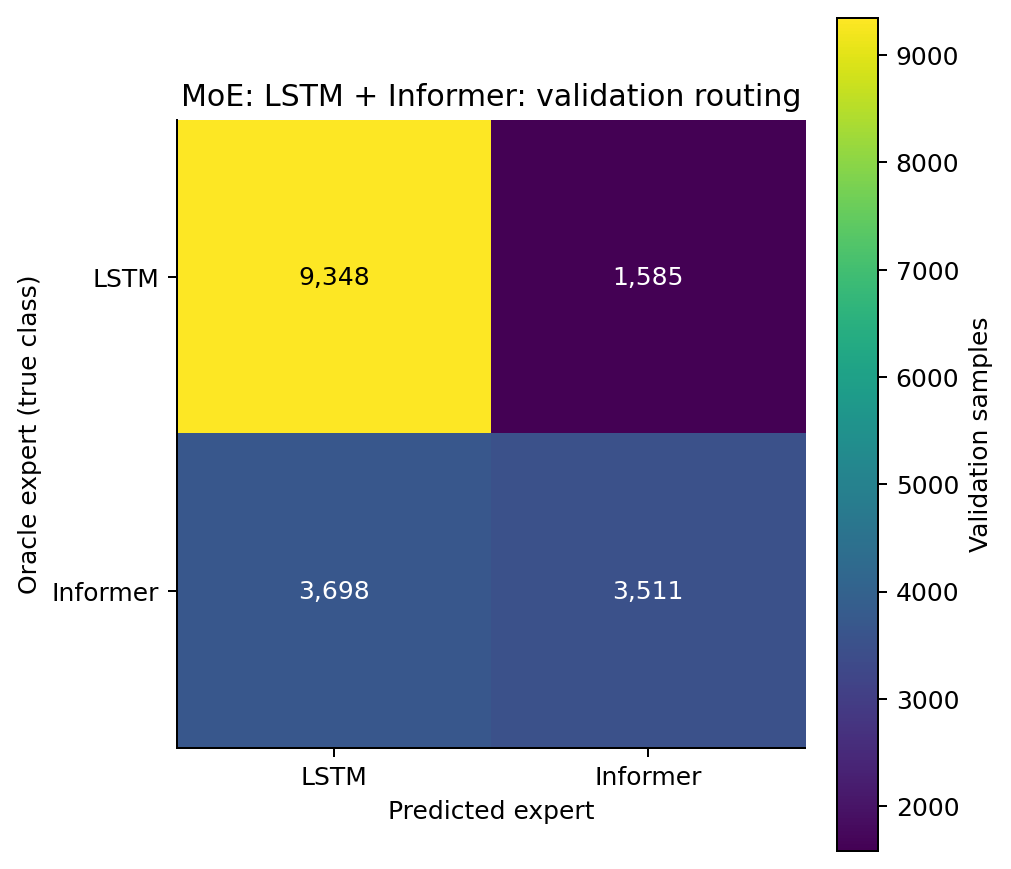

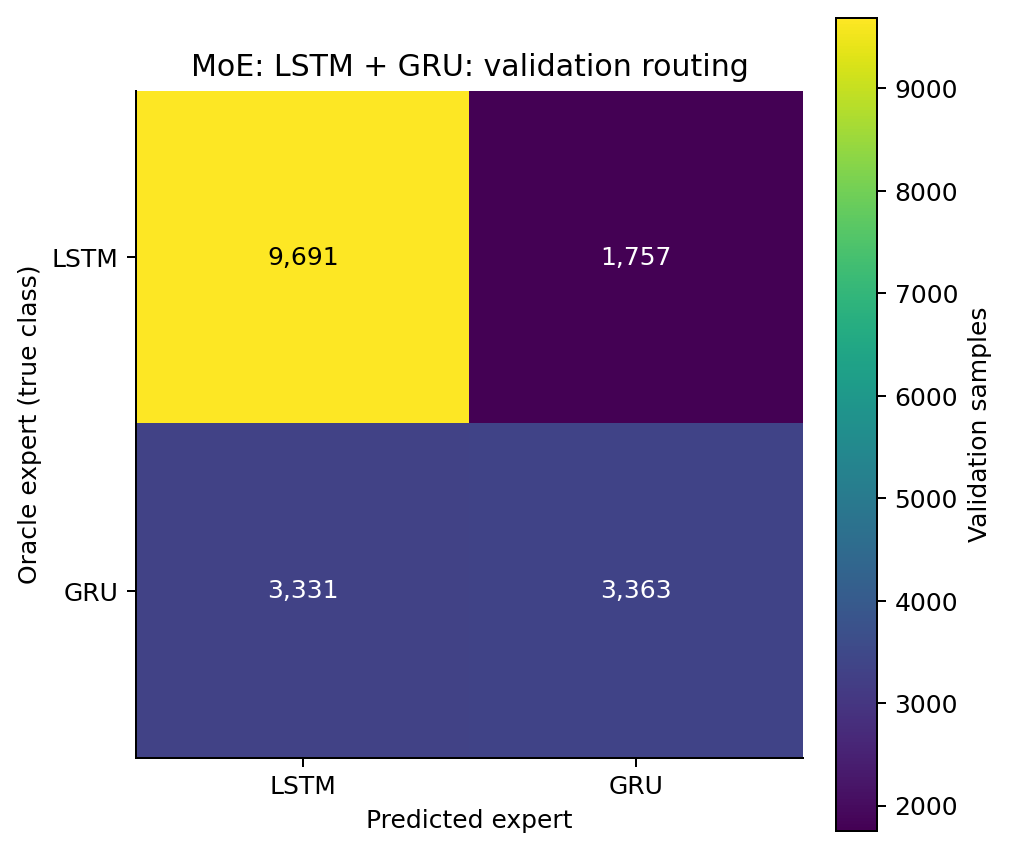

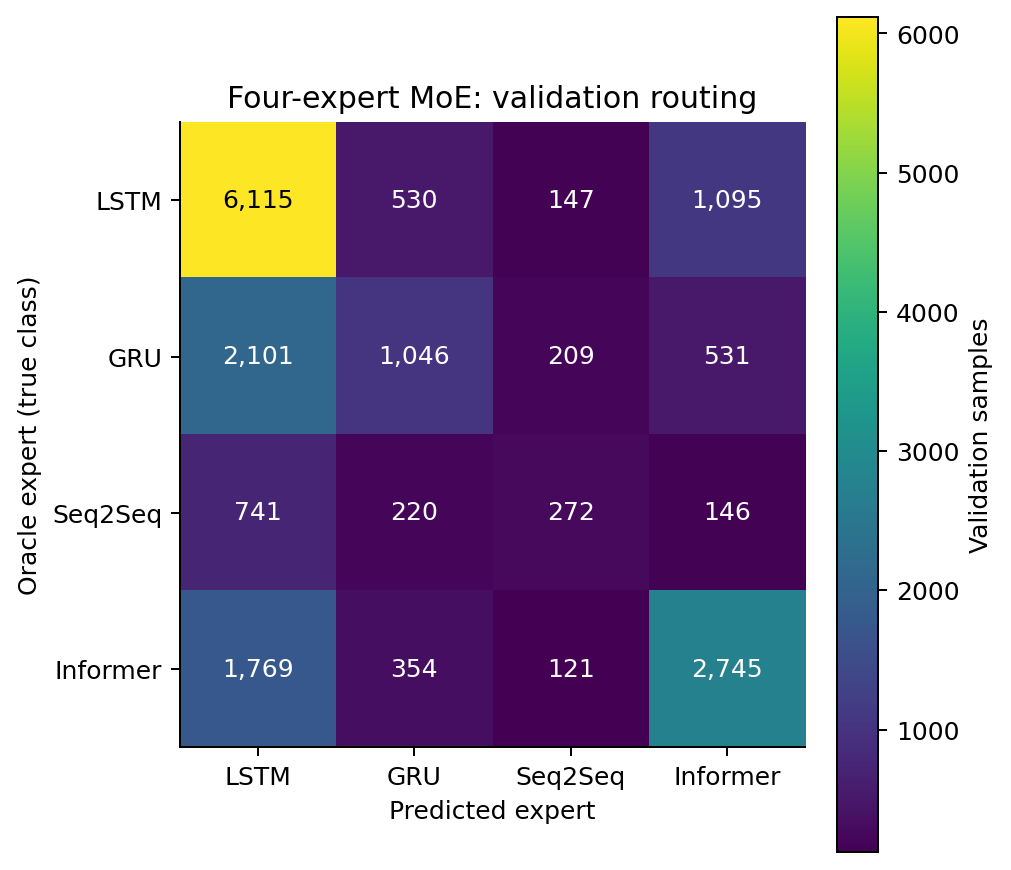

,True frequency,Predicted frequency
Expert,,
LSTM,7887,10726
GRU,3887,2150
Seq2Seq,1379,749
Informer,4989,4517


Four-class oracle-class accuracy: **56.10%**.

In [9]:
def confusion_plot(matrix, names, title, filename):
    cm = np.asarray(matrix, dtype=int)
    fig, ax = plt.subplots(figsize=(5.5, 4.8), layout="constrained")
    im = ax.imshow(cm)
    labels = [EXPERT_LABELS[name] for name in names]
    ax.set(xticks=np.arange(len(names)), yticks=np.arange(len(names)),
           xticklabels=labels, yticklabels=labels, xlabel="Predicted expert",
           ylabel="Oracle expert (true class)", title=title)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="black" if cm[i, j] > cm.max() / 2 else "white")
    fig.colorbar(im, ax=ax, label="Validation samples")
    show_figure(fig, filename)

for model, record in routers.items():
    confusion_plot(record["confusion_matrix"], record["expert_names"],
                   f"{LABELS[model]}: validation routing", f"confusion_{model.lower()}.png")

baseline = moe_validation["MoE_4class_LSTM_router"]
full_names = baseline.get("expert_names", ["lstm", "gru", "seq2seq", "informer"])
full_cm = np.asarray(baseline["router_confusion_matrix"], dtype=int)
assert full_cm.shape == (4, 4) and full_cm.sum() == metadata["samples"]["validation"]
np.testing.assert_array_equal(full_cm.sum(axis=0), baseline["router_class_frequencies"])
assert np.isclose(np.trace(full_cm) / full_cm.sum(), baseline["router_accuracy"])
confusion_plot(full_cm, full_names, "Four-expert MoE: validation routing", "confusion_four_experts.png")
display(pd.DataFrame({
    "Expert": [EXPERT_LABELS[name] for name in full_names],
    "True frequency": full_cm.sum(axis=1),
    "Predicted frequency": full_cm.sum(axis=0),
}).set_index("Expert"))
display(Markdown(f"Four-class oracle-class accuracy: **{100 * baseline['router_accuracy']:.2f}%**."))


Both binary routers predict LSTM more frequently than its oracle frequency: 13,046 versus 10,933 samples for LSTM + Informer, and 13,022 versus 11,448 for LSTM + GRU. This indicates a validation routing preference toward LSTM relative to the oracle labels.

Oracle labels change with the expert subset. Two-class and four-class accuracies therefore refer to different classification tasks and cannot alone establish a forecasting advantage.


## 19. Physical-consistency observations

Negative specific_discharge forecasts, if present, are a physical-consistency limitation. The check counts every saved binary prediction value and the number of affected samples. It does not clip values, modify CSVs, or recalculate official metrics after post-processing.


In [10]:
negative_rows = []
for model, frame in predictions.items():
    values = frame[q_columns].to_numpy(dtype=np.float64)
    negative = values < 0
    negative_rows.append({
        "Model": LABELS[model], "Prediction values": int(values.size),
        "Negative values": int(negative.sum()),
        "Negative values (%)": 100 * float(negative.mean()),
        "Affected samples": int(negative.any(axis=1).sum()),
    })
negative_table = pd.DataFrame(negative_rows)
if not negative_table.empty:
    display(negative_table.set_index("Model").style.format({"Negative values (%)": "{:.4f}"}))
    if negative_table["Negative values"].sum():
        display(Markdown("Negative forecasts occur in the saved results. Nonnegative output "
                         "constraints or post-processing are future topics requiring separate "
                         "validation; no such change is applied here."))
    else:
        display(Markdown("No negative values were detected in the available binary prediction files."))
else:
    print("Negative-prediction analysis skipped: local binary prediction files are unavailable.")


,Prediction values,Negative values,Negative values (%),Affected samples
Model,,,,
MoE: LSTM + Informer,1343184,88013,6.5526,4218
MoE: LSTM + GRU,1343184,39874,2.9686,2530


Negative forecasts occur in the saved results. Nonnegative output constraints or post-processing are future topics requiring separate validation; no such change is applied here.

## 20. Discussion

The metric ordering changes slightly between validation and test. The four-class MoE has the lowest MAE on both splits. LSTM + GRU has the lowest validation RMSE and highest validation NSE; LSTM + Informer has the lowest test RMSE and highest test NSE. The binary test differences are small in absolute terms.

RMSE weights large residuals more strongly than MAE. On the same target array, NSE and RMSE share the same squared-error ordering, so agreement between their rankings is not independent evidence. Aggregate metrics do not identify which basins or flow regimes drive the differences.

The observed benefits over persistence support the usefulness of the reported learned forecasts for this dataset. The saved comparisons do not establish general superiority across datasets, seeds, or hydrological regimes.


In [11]:
gap = test.loc["MoE_LSTM_GRU", ["mae", "rmse", "nse"]] - test.loc[
    "MoE_LSTM_Informer", ["mae", "rmse", "nse"]]
display(pd.DataFrame({"LSTM + GRU minus LSTM + Informer (test)": gap})
        .rename(index=str.upper).style.format("{:+.8f}"))


,LSTM + GRU minus LSTM + Informer (test)
MAE,-0.00007587
RMSE,+0.00009342
NSE,-0.00067806


## 21. Limitations

- The final artifacts represent the reported runs; they contain no repeated-seed uncertainty estimates or statistical-significance tests.
- Global sample–horizon metrics are not basin-balanced summaries and do not establish performance for every basin or flow regime.
- Router labels are generated from known-target samples using trained experts; training-label generation is in-sample. Oracle-class accuracy is distinct from physical-unit forecast error.
- The individual-expert validation summary has limited stored precision; the final test summary does not include standalone expert test scores.
- Negative predictions, when detected above, are retained in the official unmodified evaluation.
- Informer is an adapted implementation; calendar embeddings and future meteorological inputs are unavailable.
- Training, inference, checkpoints, and raw/private data are not reproduced by this analysis notebook. Optional binary analyses require local files excluded from version control.

Confirmed test-row alignment is not an unresolved limitation.


## 22. Reproducibility notes

Training and evaluation were executed on **Khipu**. Native adapters are under `slurm/`; final test inference uses `slurm/predict_test.sbatch`. These wrappers call shared implementations in `scripts/` and `src/`.

For HDF5-heavy Khipu jobs, use `NUM_WORKERS=0`: multiple workers previously caused file-descriptor exhaustion (“Too many open files”). This is an operational safeguard, not a universal requirement.

Comma-separated subsets must be assigned in the shell environment before `sbatch --export=ALL`. Example for a future, separately authorized run (this notebook does not execute it):

~~~sh
EXPERTS="lstm,informer" \
ROUTER="lstm" \
ROUTER_CHECKPOINT="checkpoints/router_lstm_informer/router_lstm.pt" \
OUTPUT="outputs/final_results/test_predictions_lstm_informer.csv" \
NUM_WORKERS="0" \
sbatch --export=ALL slurm/predict_test.sbatch
~~~

The wrapper refuses an existing output path; existing final predictions must be retained. The same pattern applies to `EXPERTS="lstm,gru"` with its matching router artifact.

The 12 lightweight evidence files are explicitly allowlisted for versioning. Large prediction CSVs, the smoke CSV, raw inputs/targets, checkpoints, logs, and archives remain excluded. Figure PNGs are generated locally; figures and tables are also embedded in this notebook.

The manifest below fingerprints the exact lightweight evidence and any optional local CSVs used by this execution. Paths are repository-relative. It records provenance without exposing target arrays.


In [12]:
def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

used_paths = [ROOT / "Input/metadata.json", *[RESULTS / name for name in EVIDENCE]]
used_paths += [RESULTS / prediction_files[model] for model in predictions]
if derived_binary_models:
    used_paths.append(target_path)
manifest = pd.DataFrame([
    {"File": path.relative_to(ROOT).as_posix(), "SHA-256": sha256_file(path)}
    for path in used_paths
])
display(manifest.set_index("File"))
display(pd.DataFrame([
    {"Component": "Python", "Version": platform.python_version()},
    {"Component": "NumPy", "Version": np.__version__},
    {"Component": "pandas", "Version": pd.__version__},
    {"Component": "matplotlib", "Version": matplotlib.__version__},
]).set_index("Component"))
print("No training, router-label generation, checkpoint changes, or inference were performed.")


No training, router-label generation, checkpoint changes, or inference were performed.


,SHA-256
File,
Input/metadata.json,a4d3bcb4c7015a3dc65a644432bf6e6ddfd3133a481ceb...
outputs/final_results/validation_summary.csv,18719e0dd6718056dd2f49631ecfdd7bb30839d59be2be...
outputs/final_results/test_summary.csv,92ffb47309b8738c3abd8c216adc33aeb4522cb3647c74...
outputs/final_results/test_metrics_binary_moe.json,969f5f8017f95c2e8d46f7fcbb1c8994186e64181400b8...
outputs/final_results/test_moe_lstm_metrics.json,7661312c628fe286e114649e77f05504ef7c4ddfd2192a...
outputs/final_results/test_persistence_metrics.json,beca4dd6decb66fd8a5a65b2698c2c576f4da064eb4235...
outputs/final_results/router_lstm_gru_metrics.json,f241e0de1267aefdf79602b93e4868eea7731ca783589a...
outputs/final_results/router_lstm_informer_metrics.json,4ce5ca969ca181c649529a33922271d4ae09c462452303...
outputs/final_results/moe_lstm_baseline_validation.json,bd4a3c99e9e4cb518756889214a8c8cf699f78f893df51...


,Version
Component,
Python,3.10.11
NumPy,2.2.6
pandas,2.3.3
matplotlib,3.10.9


## 23. Conclusions

The saved final results show lower test MAE and RMSE, and higher NSE, for all reported MoEs relative to persistence. The four-expert configuration has the lowest test MAE; LSTM + Informer has the lowest test RMSE and highest NSE. LSTM + GRU has strong validation RMSE/NSE and closely comparable binary test errors.

Configurable subsets preserve the expert implementations while making participation and local router mappings explicit and reproducible. Their results demonstrate that metric-specific comparisons matter: validation and test orderings need not coincide.

The final package separates confirmed held-out evaluation from model selection and retains unmodified evidence. Per-horizon and physical-consistency analyses qualify the aggregate findings without adding unsupported significance or overall-ranking claims.
